In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('Data/dataset.csv')

print(df.shape)
df.head()

(2098, 9)


,No,Nama,JK,Tgl Lahir,Usia Saat Ukur,Tanggal Pengukuran,Berat,Tinggi,Diagnosa
0,1,A ADIB HAIKAL,0,1/9/2020,3 Tahun - 7 Bulan - 6 Hari,8/16/2023,14.9,98.0,TIDAK
1,2,A ALVIAN GHIFARI,0,8/15/2019,4 Tahun - 0 Bulan - 1 Hari,8/16/2023,15.8,104.0,TIDAK
2,3,A Arfan Maulana,0,11/13/2020,2 Tahun - 9 Bulan - 1 Hari,8/16/2023,12.7,86.0,IYA
3,4,a ariel,0,7/11/2023,0 Tahun - 1 Bulan - 5 Hari,8/16/2023,4.0,53.0,TIDAK
4,5,A BAYU NASRULLAH,0,5/16/2019,4 Tahun - 3 Bulan - 0 Hari,8/16/2023,16.9,106.0,TIDAK


In [3]:
import re

def umur_ke_bulan(teks):
    tahun = 0
    bulan = 0

    hasil_tahun = re.search(r'(\d+)\s*Tahun', str(teks))
    hasil_bulan = re.search(r'(\d+)\s*Bulan', str(teks))

    if hasil_tahun:
        tahun = int(hasil_tahun.group(1))

    if hasil_bulan:
        bulan = int(hasil_bulan.group(1))

    return tahun * 12 + bulan

df['Umur_Bulan'] = df['Usia Saat Ukur'].apply(umur_ke_bulan)

print(df[['Usia Saat Ukur','Umur_Bulan']].head())

               Usia Saat Ukur  Umur_Bulan
0  3 Tahun - 7 Bulan - 6 Hari          43
1  4 Tahun - 0 Bulan - 1 Hari          48
2  2 Tahun - 9 Bulan - 1 Hari          33
3  0 Tahun - 1 Bulan - 5 Hari           1
4  4 Tahun - 3 Bulan - 0 Hari          51


In [4]:
#Seleksi Fitur
df = df[
    [
        'JK',
        'Umur_Bulan',
        'Berat',
        'Tinggi',
        'Diagnosa'
    ]
]

print("Data Setelah Seleksi Fitur:", df.shape)
df.head()

Data Setelah Seleksi Fitur: (2098, 5)


,JK,Umur_Bulan,Berat,Tinggi,Diagnosa
0,0,43,14.9,98.0,TIDAK
1,0,48,15.8,104.0,TIDAK
2,0,33,12.7,86.0,IYA
3,0,1,4.0,53.0,TIDAK
4,0,51,16.9,106.0,TIDAK


In [5]:
#cek missing value
print(df.isnull().sum())

JK            0
Umur_Bulan    0
Berat         0
Tinggi        0
Diagnosa      0
dtype: int64


In [6]:
#Transformasi data ---> Label Encoding
print(df['Diagnosa'].unique())

# Encoding
df['Diagnosa'] = df['Diagnosa'].replace({
    'IYA': 1,
    'TIDAK': 0,
    'Ya': 1,
    'Tidak': 0
})

# Cek hasil
print(df['Diagnosa'].value_counts())
df.head()

['TIDAK' 'IYA']
Diagnosa
0    1795
1     303
Name: count, dtype: int64


,JK,Umur_Bulan,Berat,Tinggi,Diagnosa
0,0,43,14.9,98.0,0
1,0,48,15.8,104.0,0
2,0,33,12.7,86.0,1
3,0,1,4.0,53.0,0
4,0,51,16.9,106.0,0


In [7]:
#Penghapusan Duplikat Data
print("Jumlah data sebelum:", len(df))

data_terhapus = df[df.duplicated(keep='first')]

df = df.drop_duplicates()

print("Jumlah data sesudah:", len(df))
print("\nJumlah data duplikat yang dihapus:", len(data_terhapus))

Jumlah data sebelum: 2098
Jumlah data sesudah: 2028

Jumlah data duplikat yang dihapus: 70


In [8]:
print("Distribusi kelas setelah penghapusan duplikat:")
print(df['Diagnosa'].value_counts())

Distribusi kelas setelah penghapusan duplikat:
Diagnosa
0    1725
1     303
Name: count, dtype: int64


In [9]:
df.to_csv("dataset_hasil_preprocessing.csv", index=False)

print("Dataset berhasil disimpan sebagai dataset_hasil_preprocessing.csv")

Dataset berhasil disimpan sebagai dataset_hasil_preprocessing.csv


In [10]:
#Fitur dan Target
X = df[['JK', 'Umur_Bulan', 'Berat', 'Tinggi']]
y = df['Diagnosa']

#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Normalisasi
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Informasi data
print(f'Data latih : {len(X_train)}')
print(f'Data uji   : {len(X_test)}')

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

print(X_train_scaled.head())
print("\nDistribusi kelas pada Data Latih")
print(y_train.value_counts())

print("\nDistribusi kelas pada Data Uji")
print(y_test.value_counts())

Data latih : 1622
Data uji   : 406
    JK  Umur_Bulan     Berat    Tinggi
0  1.0    0.116667  0.248908  0.246377
1  0.0    0.783333  0.379913  0.617391
2  1.0    0.416667  0.393013  0.623188
3  0.0    0.900000  0.567686  0.855072
4  1.0    0.283333  0.331878  0.434783

Distribusi kelas pada Data Latih
Diagnosa
0    1380
1     242
Name: count, dtype: int64

Distribusi kelas pada Data Uji
Diagnosa
0    345
1     61
Name: count, dtype: int64


In [11]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
akurasi = accuracy_score(y_test, y_pred)

print("Akurasi:", round(akurasi*100,2), "%")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Akurasi: 96.06 %

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       345
           1       0.86      0.89      0.87        61

    accuracy                           0.96       406
   macro avg       0.92      0.93      0.92       406
weighted avg       0.96      0.96      0.96       406



c:\Users\rendi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[336   9]
 [  7  54]]


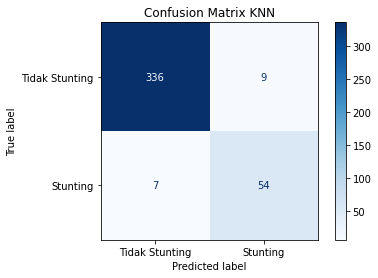

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Tidak Stunting', 'Stunting']
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix KNN')
plt.show()

In [14]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))

Accuracy : 0.9605911330049262
Precision: 0.8571428571428571
Recall   : 0.8852459016393442
F1-Score : 0.8709677419354839


## **Simpan Model dan Scaler**



In [15]:
joblib.dump(knn, "model_knn.pkl")

['model_knn.pkl']

In [16]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']